# NYC Census Block Group Adjacency Matrix Generation

This notebook generates and visualizes the spatial adjacency network for Census Block Groups (CBGs) in NYC.
It uses a geometric buffer approach to define adjacency relationships.


In [ ]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../../for_paper/adjacency')
sys.path.insert(0, '../../..')

import constants as c
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tract_weights import GeometryWeightsGenerator
from geometry_config import GeometryType, get_geometry_paths
from IPython.display import display, HTML

%matplotlib inline


## Generate Weights

First, let's compute the custom geometric weights matrix for Census Block Groups.
We use a 300ft buffer distance (smaller than the 500ft used for Census Tracts due to smaller geometry sizes).


In [2]:
# Get paths for CBG geometry
paths = get_geometry_paths(GeometryType.CBG)
print(f"CBG GeoJSON: {paths.geojson_path}")
print(f"Adjacency output dir: {paths.adjacency_dir}")


CBG GeoJSON: /share/ju/matt/bayflood/data/cbg-nyc-2020.geojson
Adjacency output dir: /share/ju/matt/bayflood/data/adjacency/cbg_cg_300


In [3]:
# Initialize weights generator for Census Block Groups
generator = GeometryWeightsGenerator(GeometryType.CBG)

# Compute custom geometric weights with 300ft buffer
# (smaller buffer than CT due to smaller geometry sizes)
custom_geometric_weights = generator.compute_custom_geometric_weights(buffer_dist=300, debug=True)


  Component sizes: [6362, 343, 4, 1, 1, 1, 1]
  Found 4 isolated areas.


In [4]:
# Inspect the weights results
custom_geometric_weights


{'custom_geometric': WeightsAnalysis(weights_matrix=array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(6713, 6713)), n_connections=27475, isolated_areas=[1495, 3345, 3849, 4868], avg_connections=np.float64(8.185758975122896), description='Custom Geometric with 300ft buffer')}

In [5]:
# Print summary statistics
cg = custom_geometric_weights['custom_geometric']
print(f"=== CBG Adjacency Network Statistics ===")
print(f"Total CBGs: {cg.weights_matrix.shape[0]}")
print(f"Total connections: {cg.n_connections}")
print(f"Average connections per CBG: {cg.avg_connections:.2f}")
print(f"Isolated CBGs: {len(cg.isolated_areas)}")
if cg.isolated_areas:
    print(f"Isolated CBG indices: {cg.isolated_areas[:10]}..." if len(cg.isolated_areas) > 10 else f"Isolated CBG indices: {cg.isolated_areas}")


=== CBG Adjacency Network Statistics ===
Total CBGs: 6713
Total connections: 27475
Average connections per CBG: 8.19
Isolated CBGs: 4
Isolated CBG indices: [1495, 3345, 3849, 4868]


In [6]:
# Export weights to adjacency list files
output_dir = paths.adjacency_dir
os.makedirs(output_dir, exist_ok=True)
node1_path, node2_path = generator.export_adjacency_lists("custom_geometric", output_dir=output_dir)
print(f"Exported adjacency lists to:")
print(f"  {node1_path}")
print(f"  {node2_path}")


Exported adjacency lists to:
  /share/ju/matt/bayflood/data/adjacency/cbg_cg_300/cbg_nyc_adj_list_custom_geometric_node1.txt
  /share/ju/matt/bayflood/data/adjacency/cbg_cg_300/cbg_nyc_adj_list_custom_geometric_node2.txt


## Visualize Adjacency Network


In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Enable LaTeX plotting (matching CT notebook style)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

def create_academic_map(gdf, adj_matrix, method_name, isolated_nodes=None):
    """
    Create a map visualization of the adjacency network.
    Replicates the style from the CT geometric_buffer_adjacency.ipynb notebook.
    """
    # Project to Web Mercator for visualization
    gdf_proj = gdf.to_crs('EPSG:3857')
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot the census boundaries by borough
    gdf_proj.plot(ax=ax, column='BoroName', categorical=True, 
                 alpha=0.4, legend=True, legend_kwds={'loc': 'upper left'})

    # Style the legend (matching CT notebook)
    leg = ax.get_legend()
    leg.set_title('Borough', prop={'size': 16})
    for label in leg.get_texts():
        label.set_fontsize(14)
    
    # Add adjacency lines (all edges, matching CT style)
    for i in range(adj_matrix.shape[0]):
        for j in range(i+1, adj_matrix.shape[1]):
            if adj_matrix[i,j] == 1:
                cent1 = gdf_proj.iloc[i].geometry.centroid
                cent2 = gdf_proj.iloc[j].geometry.centroid
                ax.plot([cent1.x, cent2.x], [cent1.y, cent2.y], 
                       color='blue', alpha=0.4, linewidth=0.5)
    
    # Highlight isolated nodes if provided
    if isolated_nodes:
        for idx in isolated_nodes:
            centroid = gdf_proj.iloc[idx].geometry.centroid
            ax.plot(centroid.x, centroid.y, 'ro', markersize=5, alpha=0.7)
    
    # Remove axes for cleaner map presentation
    ax.set_axis_off()
    
    return fig, ax


In [8]:
# Load CBG geometry for visualization
gdf = gpd.read_file(str(paths.geojson_path))
gdf = gdf.to_crs(epsg=2263)

# Add BoroName based on COUNTYFP (NYC county FIPS codes)
county_to_boro = {
    '005': 'Bronx',
    '047': 'Brooklyn', 
    '061': 'Manhattan',
    '081': 'Queens',
    '085': 'Staten Island'
}
gdf['BoroName'] = gdf['COUNTYFP'].map(county_to_boro)

print(f"Loaded {len(gdf)} Census Block Groups")
print(f"By borough: {gdf['BoroName'].value_counts().to_dict()}")


Loaded 6713 Census Block Groups
By borough: {'Brooklyn': 2121, 'Queens': 1788, 'Manhattan': 1286, 'Bronx': 1174, 'Staten Island': 344}


Plotting 27475 edges... (this may take a moment)
Saved to ../../../papers/natcities_bayflood_2025/figures/cbg_adjacency_map.png


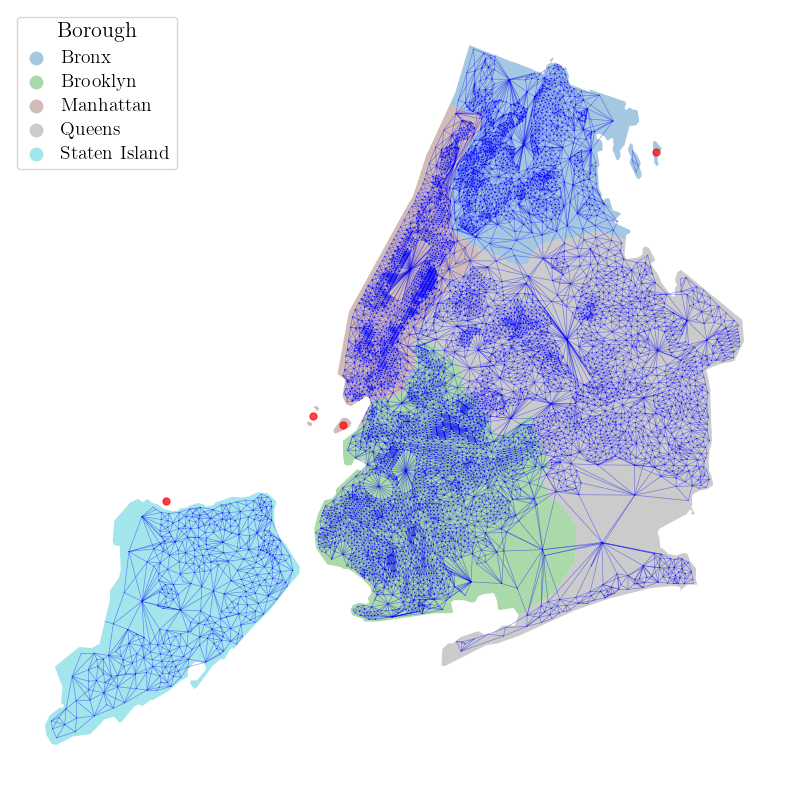

In [9]:
# Create map for custom geometric method (matching CT notebook style)
adj_matrix = custom_geometric_weights['custom_geometric'].weights_matrix
isolated_nodes = custom_geometric_weights['custom_geometric'].isolated_areas

print(f"Plotting {int(adj_matrix.sum()/2)} edges... (this may take a moment)")
fig, ax = create_academic_map(gdf, adj_matrix, 'Custom Geometric Method', isolated_nodes)

# Save figure
output_path = f'{c.PAPER_PATH}/figures/cbg_adjacency_map.png'
plt.savefig(output_path, dpi=200, bbox_inches='tight')
print(f"Saved to {output_path}")


## Compare with Census Tract Network


In [10]:
# Load CT adjacency for comparison
ct_paths = get_geometry_paths(GeometryType.CT)
ct_node1 = ct_paths.adjacency_node1_path('custom_geometric')

if ct_node1.exists():
    with open(ct_node1) as f:
        ct_n_edges = len(f.readlines())
    
    cbg_n_edges = cg.n_connections
    
    print("=== Network Comparison ===")
    print(f"Census Tracts:")
    print(f"  - 2,325 areas")
    print(f"  - {ct_n_edges} edges")
    print(f"  - ~{ct_n_edges/2325:.1f} avg connections")
    print()
    print(f"Census Block Groups:")
    print(f"  - {cg.weights_matrix.shape[0]} areas")
    print(f"  - {cbg_n_edges} edges")
    print(f"  - ~{cg.avg_connections:.1f} avg connections")
    print()
    print(f"Ratio: CBG has {cbg_n_edges/ct_n_edges:.1f}x more edges")
else:
    print("CT adjacency not found for comparison")


=== Network Comparison ===
Census Tracts:
  - 2,325 areas
  - 8281 edges
  - ~3.6 avg connections

Census Block Groups:
  - 6713 areas
  - 27475 edges
  - ~8.2 avg connections

Ratio: CBG has 3.3x more edges
